In [1]:
import pandas as pd
import os
from utils.ml_utils_v2 import EmissionsPredictionPipeline, MultiOutputEmissionsPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
SIMULATION_DIR_PATH = os.path.join(SSP_DIR_PATH, "sisepuede_summary_results_run_sisepuede_run_2025-08-10t10;29;30.545790")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [4]:
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_v4.2.csv")
training_df = pd.read_csv(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_frac_enfu_transmission_loss_fuel_electricity,group_6_nemomod_en,group_7_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,group_8_frac_fgtv_reduction_in_fugitive_leaks,group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_10_efficfactor_enfu_industrial_energy_fuel,...,group_52_gdp_mmm_usd,group_53_population_gnrl,group_54_elasticity_scoe_enerdem_per,group_55_elasticity_trde_mtkm_to_gdp_freight,group_56_elasticity_trde_pkm_to_gdppc,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,technical_cost
0,0.709094,0.362421,0.352636,0.246076,0.230763,0.231633,0.357253,0.416035,0.191546,0.668268,...,0.065254,0.452244,0.395609,0.190891,0.681412,0.199758,0.969220,59.720047,3553.270010,-42.336438
1,0.355127,0.388826,0.495092,0.282101,0.198981,0.620631,0.428909,0.192468,0.035291,0.729170,...,0.017979,0.912414,0.894009,0.046745,0.000798,0.725034,0.902345,30.972144,3028.607700,-21.656242
2,0.970473,0.436334,0.243523,0.227546,0.467160,0.102438,0.605842,0.087344,0.997124,0.240382,...,0.416929,0.832413,0.406103,0.929365,0.575067,0.208350,0.175365,92.551550,4127.536839,-40.157702
3,0.605323,0.210722,0.661197,0.823838,0.003365,0.990644,0.114855,0.215559,0.363979,0.854653,...,0.778987,0.995629,0.994153,0.946893,0.506764,0.227383,0.113647,11.015231,2668.240547,-53.155978
4,0.247035,0.704965,0.523551,0.535350,0.345173,0.482609,0.894310,0.862094,0.236449,0.329243,...,0.918567,0.183357,0.397512,0.328322,0.362234,0.947292,0.764492,41.876734,3343.173022,-77.798140


## EDA

In [5]:
edau = EDAUtils()

In [6]:
target_cols = [col for col in training_df.columns if "emission" in col] + ["technical_cost"]
target_cols

['emission_avg_last_five_years', 'emission_total', 'technical_cost']

In [7]:
lhs_group_cols = [col for col in training_df.columns if col.startswith("group_")]
lhs_group_cols

['group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha',
 'group_2_frac_agrc_agriculture_production_lost',
 'group_3_frac_agrc',
 'group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture',
 'group_5_frac_enfu_transmission_loss_fuel_electricity',
 'group_6_nemomod_en',
 'group_7_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis',
 'group_8_frac_fgtv_reduction_in_fugitive_leaks',
 'group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel',
 'group_10_efficfactor_enfu_industrial_energy_fuel',
 'group_11_scalar_inen_energy_demand',
 'group_12_frac_inen_energy',
 'group_13_frac_ippu_cement_clinker',
 'group_14_ef_ippu_tonne_c',
 'group_15_ef_ippu_tonne_n2o_per',
 'group_16_ef_ippu_tonne_c',
 'group_17_pij_lndu',
 'group_18_frac_lndu_improved_pastures',
 'group_19_lndu_reallocation_factor',
 'group_20_gasrf_lsmm_biogas_anaerobic',
 'group_21_frac_lvst_mm',
 'group_22_frac_lvst_mm',
 'group_23_frac_lvst_mm_chickens',
 'group_24_ef_lvst_entferm',
 'group_25_frac_gnrl_eating_red_meat

In [8]:
training_df[target_cols].describe()

,emission_avg_last_five_years,emission_total,technical_cost
count,1988.000000,1988.000000,1988.000000
mean,104.749732,4266.429562,-inf
std,218.886143,3463.127200,NaN
min,-16.071475,1726.857850,-inf
25%,34.913576,3145.931248,-90.725513
50%,53.564501,3457.359997,-50.248617
75%,72.663746,3798.960870,-20.255423
max,1524.495400,26664.633567,421.697883


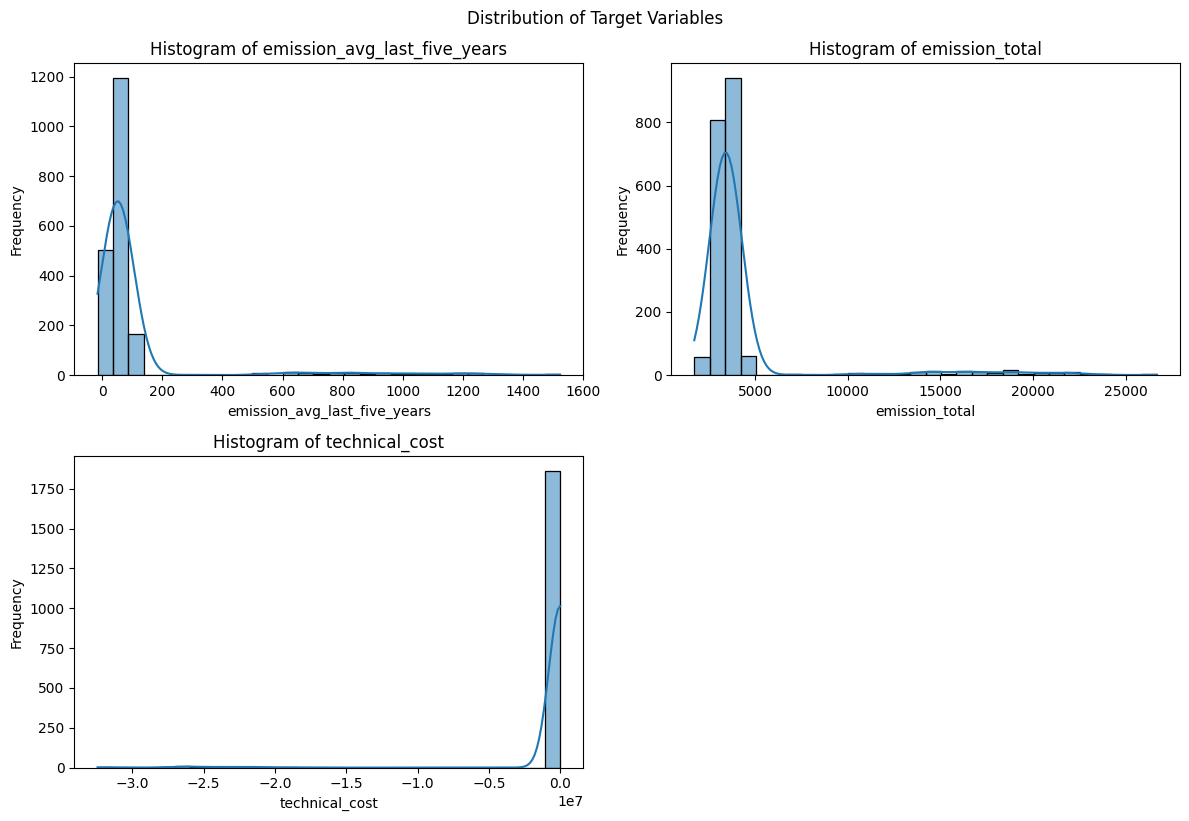

In [9]:
edau.plot_multiple_histograms(training_df, target_cols, title="Distribution of Target Variables")

In [10]:
edau.get_target_var_corr(training_df, "emission_total")
edau.get_target_var_corr(training_df, "emission_avg_last_five_years")
edau.get_target_var_corr(training_df, "technical_cost")


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
emission_total                 : 1.0000
emission_avg_last_five_years   : 0.9894
technical_cost                 : 0.9187
group_6_nemomod_en             : 0.1412
group_44_frac_waso             : 0.1016


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
emission_avg_last_five_years   : 1.0000
emission_total                 : 0.9894
technical_cost                 : 0.9224
group_6_nemomod_en             : 0.1265


Correlation with target variable 'technical_cost' (threshold: 0.1):
--------------------------------------------------
technical_cost                 : 1.0000
emission_avg_last_five_years   : 0.9224
emission_total                 : 0.9187



In [11]:
# Find constant / near-constant cols
# const_cols = edau.find_constant_columns(training_df)
# near_const_cols = edau.find_near_constant_columns(training_df, threshold=1e-2)
# print("Constant:", const_cols)
# print("Near-constant:", near_const_cols)

In [12]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'emission_avg_last_five_years': 4.225352112676056, 'emission_total': 4.527162977867203}


/opt/miniconda3/envs/ssp_la/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1158: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean


## Data Cleaning

In [13]:
dcu = DataCleaningUtils()

In [14]:
training_df.shape

(1988, 61)

In [15]:
# Check those -inf values in technical_cost
technical_cost_neg_inf = training_df[training_df["technical_cost"] == -np.inf]
technical_cost_neg_inf

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_frac_enfu_transmission_loss_fuel_electricity,group_6_nemomod_en,group_7_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,group_8_frac_fgtv_reduction_in_fugitive_leaks,group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_10_efficfactor_enfu_industrial_energy_fuel,...,group_52_gdp_mmm_usd,group_53_population_gnrl,group_54_elasticity_scoe_enerdem_per,group_55_elasticity_trde_mtkm_to_gdp_freight,group_56_elasticity_trde_pkm_to_gdppc,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,technical_cost
209,0.008507,0.409542,0.305124,0.932760,0.513969,0.324088,0.838422,0.392037,0.199936,0.945097,...,0.230926,0.607610,0.202171,0.698815,0.327581,0.081319,0.456625,682.112795,16211.125741,-inf
210,0.197687,0.295225,0.201240,0.143685,0.825065,0.712891,0.780250,0.357200,0.296128,0.972306,...,0.324864,0.254842,0.368670,0.118828,0.742308,0.994147,0.897887,1006.429076,16164.072605,-inf
211,0.631550,0.077064,0.813304,0.371919,0.112670,0.223096,0.445901,0.320361,0.835811,0.037066,...,0.835456,0.713297,0.815415,0.272374,0.086723,0.127824,0.455666,1517.132724,23871.880175,-inf
212,0.513249,0.840344,0.154165,0.683018,0.640022,0.791819,0.553474,0.904200,0.830685,0.316147,...,0.300208,0.534936,0.424729,0.918477,0.138771,0.585788,0.724585,796.750125,14316.578896,-inf
213,0.385538,0.009047,0.444493,0.495390,0.753722,0.604814,0.557255,0.163698,0.761471,0.441861,...,0.426621,0.195372,0.762829,0.173827,0.553646,0.245645,0.883382,1335.006796,22116.678912,-inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1572,0.481475,0.530208,0.349323,0.203599,0.178935,0.158221,0.302795,0.279189,0.103973,0.741374,...,0.543774,0.732839,0.964297,0.305255,0.163516,0.979787,0.993836,681.793662,11856.935259,-inf
1573,0.250174,0.841593,0.004605,0.258177,0.334152,0.205953,0.571430,0.876590,0.100328,0.811310,...,0.771430,0.696022,0.806033,0.862978,0.920705,0.697773,0.405319,1253.766865,21336.388102,-inf
1574,0.915783,0.287895,0.966175,0.125778,0.658122,0.098464,0.483406,0.043541,0.860653,0.228707,...,0.492949,0.581036,0.358664,0.392939,0.542060,0.046537,0.124567,1217.473237,19049.328064,-inf
1575,0.060175,0.973928,0.437427,0.742911,0.293216,0.601181,0.755772,0.274978,0.400264,0.927114,...,0.627306,0.772501,0.099814,0.320775,0.759127,0.927609,0.004263,547.204487,10294.944401,-inf


In [16]:
# filter out -inf values in technical_cost
training_df = training_df[training_df["technical_cost"] != -np.inf]
training_df.shape

(1904, 61)

In [17]:
training_df_cleaned = dcu.remove_outliers(training_df)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape after removing outliers: (1864, 61)


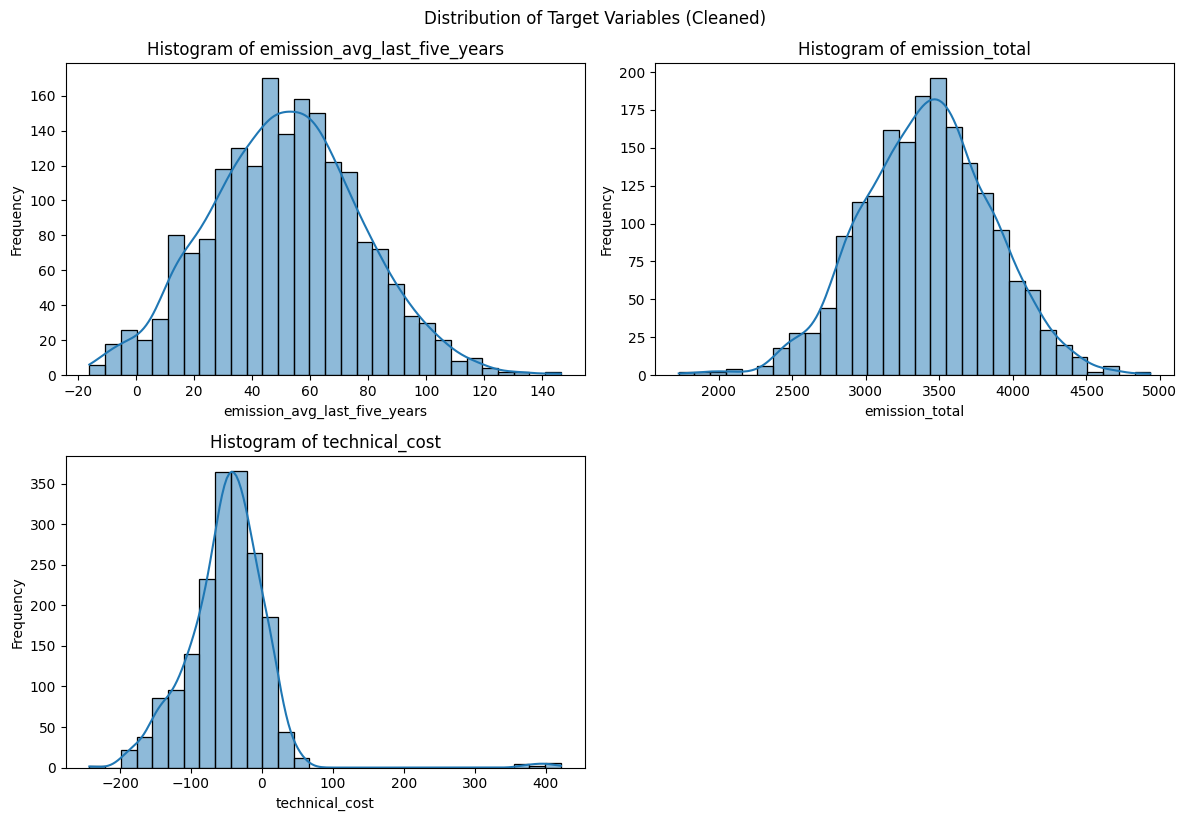

In [18]:
edau.plot_multiple_histograms(training_df_cleaned, target_cols, title="Distribution of Target Variables (Cleaned)")

In [19]:
outliers = edau.find_outlier_columns(training_df_cleaned, z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'emission_avg_last_five_years': 0.3218884120171674, 'emission_total': 0.5364806866952789, 'technical_cost': 0.7510729613733905}


In [20]:
edau.get_target_var_corr(training_df_cleaned, "emission_total")
edau.get_target_var_corr(training_df_cleaned, "emission_avg_last_five_years")
edau.get_target_var_corr(training_df_cleaned, "technical_cost")


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
emission_total                 : 1.0000
emission_avg_last_five_years   : 0.9818
group_6_nemomod_en             : 0.6959
group_12_frac_inen_energy      : 0.5251
technical_cost                 : 0.3880
group_26_frac_ippu_production_with_co2_capture : 0.1955
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.1669
group_51_exports_enfu_pj_fuel  : 0.1526
group_11_scalar_inen_energy_demand : 0.1344
group_34_fuelefficiency_trns   : 0.1226
group_10_efficfactor_enfu_industrial_energy_fuel : 0.1182
group_36_frac_trns_fuelmix_road_light : 0.1054
group_38_frac_trns_fuelmix     : 0.1041


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
emission_avg_last_five_years   : 1.0000
emission_total                 : 0.9818
group_6_nemomod_en             : 0.6313
group_12_frac_inen_energ

In [21]:
training_df_cleaned[target_cols].describe()

,emission_avg_last_five_years,emission_total,technical_cost
count,1864.000000,1864.000000,1864.000000
mean,51.380495,3415.634772,-49.657390
std,26.077179,443.128262,60.379448
min,-16.071475,1726.857850,-243.327372
25%,33.470507,3129.694779,-80.577208
50%,51.418497,3421.605749,-46.411899
75%,69.047899,3697.927269,-17.834359
max,146.415870,4934.815677,421.697883


In [22]:
# sns.pairplot(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

In [23]:
# edau.plot_correlation_matrix(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

## ML

### Individual Training

In [24]:
# negative_emissions_df = training_df_cleaned[lhs_group_cols + ["total_negative_emissions"]]
# positive_emissions_df = training_df_cleaned[lhs_group_cols + ["total_positive_emissions"]]


In [25]:
# negative_epp = EmissionsPredictionPipeline(
#     df=negative_emissions_df,
#     target="total_negative_emissions",
#     test_size=0.2,
#     random_state=42,
# )

# negative_epp.run(tune=False, log_transform=False, create_plots=False)

In [26]:
# positive_epp = EmissionsPredictionPipeline(
#     df=positive_emissions_df,
#     target="total_positive_emissions",
#     test_size=0.2,
#     random_state=42,
# )
# positive_epp.run(tune=False, log_transform=False, create_plots=False)

### Multi Output Training


=== XGB ===
emission_total                
  Train → MAE: 0.2022, RMSE: 0.3124, R²: 1.0000, SMAPE: 0.0%
   Test → MAE: 34.2964, RMSE: 124.2676, R²: 0.9278, SMAPE: 1.0%
emission_avg_last_five_years  
  Train → MAE: 0.0130, RMSE: 0.0198, R²: 1.0000, SMAPE: 0.1%
   Test → MAE: 2.1261, RMSE: 6.2537, R²: 0.9460, SMAPE: 6.2%
technical_cost                
  Train → MAE: 0.0345, RMSE: 0.0519, R²: 1.0000, SMAPE: 0.3%
   Test → MAE: 6.8099, RMSE: 37.7622, R²: 0.7152, SMAPE: 13.3%

=== MeanBaseline ===
emission_total                
  Train → MAE: 349.8470, RMSE: 437.7115, R²: 0.0000, SMAPE: 10.4%
   Test → MAE: 356.7938, RMSE: 463.8843, R²: -0.0065, SMAPE: 10.5%
emission_avg_last_five_years  
  Train → MAE: 20.7825, RMSE: 25.8377, R²: 0.0000, SMAPE: 45.3%
   Test → MAE: 21.1005, RMSE: 26.9958, R²: -0.0061, SMAPE: 44.5%
technical_cost                
  Train → MAE: 39.3262, RMSE: 57.4597, R²: 0.0000, SMAPE: 78.0%
   Test → MAE: 45.9331, RMSE: 70.7989, R²: -0.0013, SMAPE: 81.1%

=== MedianBaseli

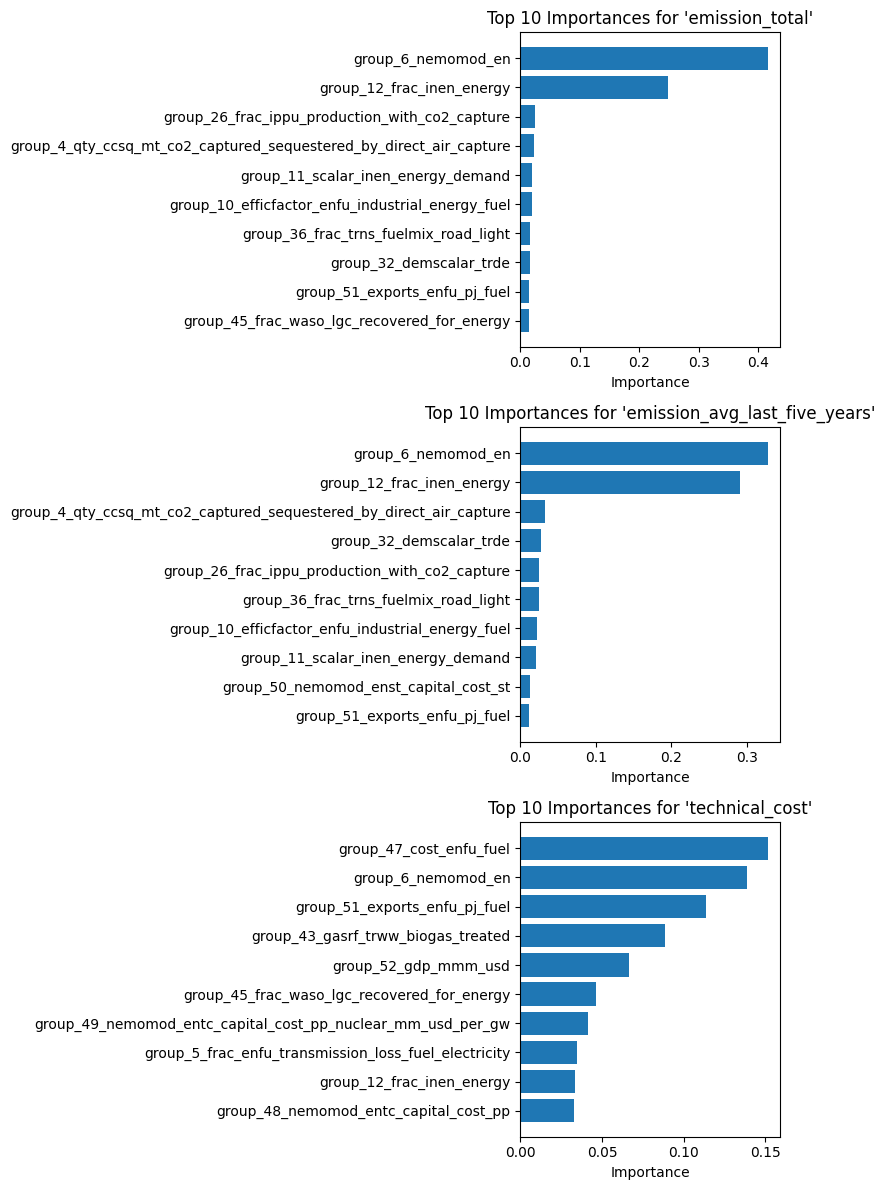

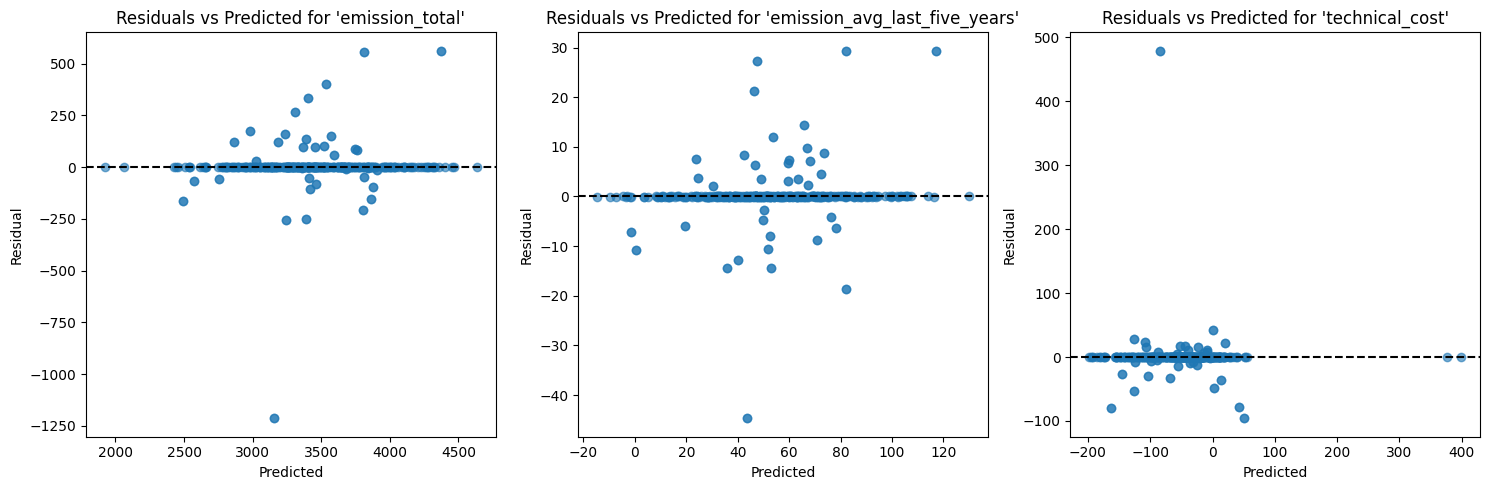

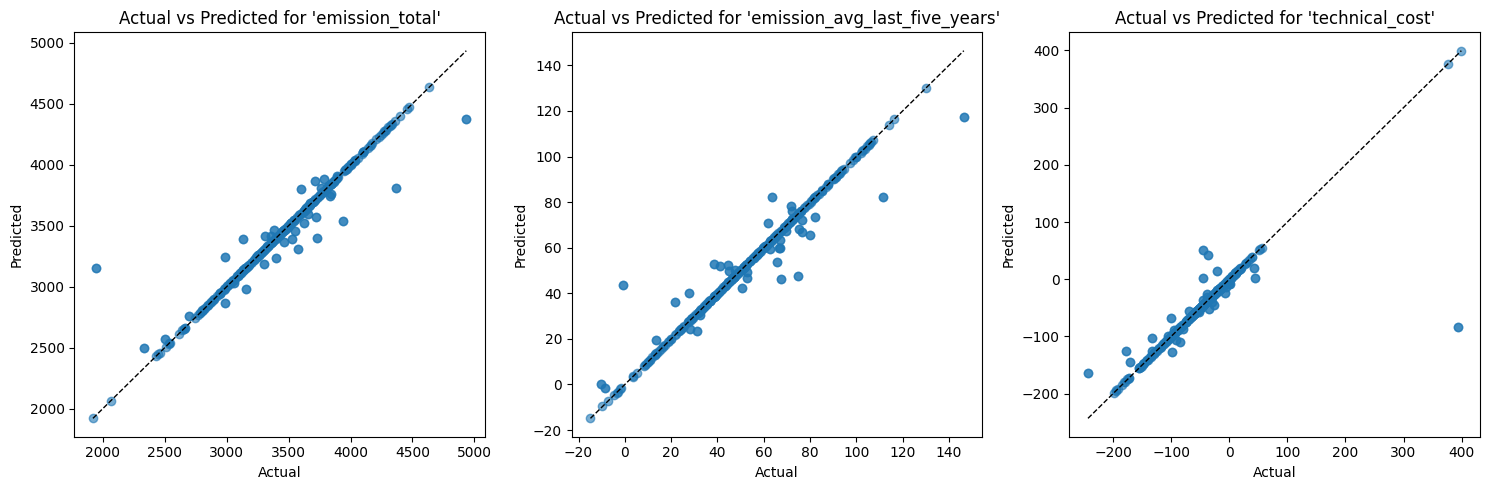

In [27]:
mulp = MultiOutputEmissionsPipeline(df=training_df_cleaned, targets=["emission_total", "emission_avg_last_five_years", "technical_cost"])
mulp.run(tune=False, log_transform=False, plot_figures=True)

## Save the trained and tuned model and use it to predict new data

In [29]:
training_df_cleaned.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_frac_enfu_transmission_loss_fuel_electricity,group_6_nemomod_en,group_7_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,group_8_frac_fgtv_reduction_in_fugitive_leaks,group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_10_efficfactor_enfu_industrial_energy_fuel,...,group_52_gdp_mmm_usd,group_53_population_gnrl,group_54_elasticity_scoe_enerdem_per,group_55_elasticity_trde_mtkm_to_gdp_freight,group_56_elasticity_trde_pkm_to_gdppc,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,technical_cost
0,0.709094,0.362421,0.352636,0.246076,0.230763,0.231633,0.357253,0.416035,0.191546,0.668268,...,0.065254,0.452244,0.395609,0.190891,0.681412,0.199758,0.969220,59.720047,3553.270010,-42.336438
1,0.355127,0.388826,0.495092,0.282101,0.198981,0.620631,0.428909,0.192468,0.035291,0.729170,...,0.017979,0.912414,0.894009,0.046745,0.000798,0.725034,0.902345,30.972144,3028.607700,-21.656242
2,0.970473,0.436334,0.243523,0.227546,0.467160,0.102438,0.605842,0.087344,0.997124,0.240382,...,0.416929,0.832413,0.406103,0.929365,0.575067,0.208350,0.175365,92.551550,4127.536839,-40.157702
3,0.605323,0.210722,0.661197,0.823838,0.003365,0.990644,0.114855,0.215559,0.363979,0.854653,...,0.778987,0.995629,0.994153,0.946893,0.506764,0.227383,0.113647,11.015231,2668.240547,-53.155978
4,0.247035,0.704965,0.523551,0.535350,0.345173,0.482609,0.894310,0.862094,0.236449,0.329243,...,0.918567,0.183357,0.397512,0.328322,0.362234,0.947292,0.764492,41.876734,3343.173022,-77.798140


In [30]:
# Get a single row from training_df_cleaned for prediction
single_row = training_df_cleaned.iloc[0].drop(["emission_total", "emission_avg_last_five_years", "technical_cost"])
single_row = single_row.to_frame().T  # Convert to DataFrame
single_row

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_frac_enfu_transmission_loss_fuel_electricity,group_6_nemomod_en,group_7_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,group_8_frac_fgtv_reduction_in_fugitive_leaks,group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_10_efficfactor_enfu_industrial_energy_fuel,...,group_49_nemomod_entc_capital_cost_pp_nuclear_mm_usd_per_gw,group_50_nemomod_enst_capital_cost_st,group_51_exports_enfu_pj_fuel,group_52_gdp_mmm_usd,group_53_population_gnrl,group_54_elasticity_scoe_enerdem_per,group_55_elasticity_trde_mtkm_to_gdp_freight,group_56_elasticity_trde_pkm_to_gdppc,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use
0,0.709094,0.362421,0.352636,0.246076,0.230763,0.231633,0.357253,0.416035,0.191546,0.668268,...,0.115895,0.456909,0.389376,0.065254,0.452244,0.395609,0.190891,0.681412,0.199758,0.96922


In [31]:
# Predict using the trained model
predictions = mulp.predict(single_row)
print("Predictions for single row:")
print(predictions)

Predictions for single row:
   emission_total  emission_avg_last_five_years  technical_cost
0     3553.051025                     59.735683      -42.340782


In [32]:
# Save the trained model
xgb_pipeline = mulp.pipelines["XGB"]
TRAINED_MODELS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
model_file_name = "xgb_pipeline_5.2.pkl"
os.makedirs(TRAINED_MODELS_DIR, exist_ok=True)

MODEL_PATH = os.path.join(TRAINED_MODELS_DIR, model_file_name)
if os.path.exists(MODEL_PATH):
    print(f"Model {model_file_name} already exists at {MODEL_PATH}. Make sure you don't overwrite an existing model.")
else:
    print(f"Saving model {model_file_name} to {MODEL_PATH}.")
    joblib.dump(xgb_pipeline, MODEL_PATH)


Saving model xgb_pipeline_5.2.pkl to /Users/tony/Documents/sisepuede_modeling/ssp_louisiana/metamodel/notebooks/trained_models/xgb_pipeline_5.2.pkl.


In [33]:
# Load the trained model and test predictions
xgb_pipeline_loaded = joblib.load(MODEL_PATH)

In [34]:
# Predict using the trained model
predictions = mulp.predict(single_row, ml_pipeline=xgb_pipeline_loaded)
print("Predictions for single row:")
print(predictions)

Predictions for single row:
   emission_total  emission_avg_last_five_years  technical_cost
0     3553.051025                     59.735683      -42.340782
